# CNN Simple - Clasificacion de Insectos BIOSCAN

CNN para clasificar **11 ordenes de insectos** usando el dataset BIOSCAN.
Sigue el mismo patron del notebook de referencia: bloques Conv2d + ReLU + MaxPool2d.

## 1. Imports

In [5]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

Dispositivo: cpu


## 2. Dataset

In [6]:
DATASET_DIR = r'c:\\Users\\lucia\\Desktop\\CNN dataset\\dataset_v2'
IMG_SIZE    = 128
BATCH_SIZE  = 32

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(os.path.join(DATASET_DIR, 'train'), transform=transform_train)
val_dataset   = ImageFolder(os.path.join(DATASET_DIR, 'val'),   transform=transform_val)
test_dataset  = ImageFolder(os.path.join(DATASET_DIR, 'test'),  transform=transform_val)

dataloader = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True),
    'val':   DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
    'test':  DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
}

classes   = train_dataset.classes
n_classes = len(classes)
print('Clases ({}):'.format(n_classes), classes)
print('Train:', len(train_dataset), '| Val:', len(val_dataset), '| Test:', len(test_dataset))

Clases (11): ['Blattodea', 'Coleoptera', 'Diptera', 'Hemiptera', 'Hymenoptera', 'Lepidoptera', 'Neuroptera', 'Orthoptera', 'Psocodea', 'Thysanoptera', 'Trichoptera']
Train: 17749 | Val: 3803 | Test: 3804


## 3. Ejemplos del dataset

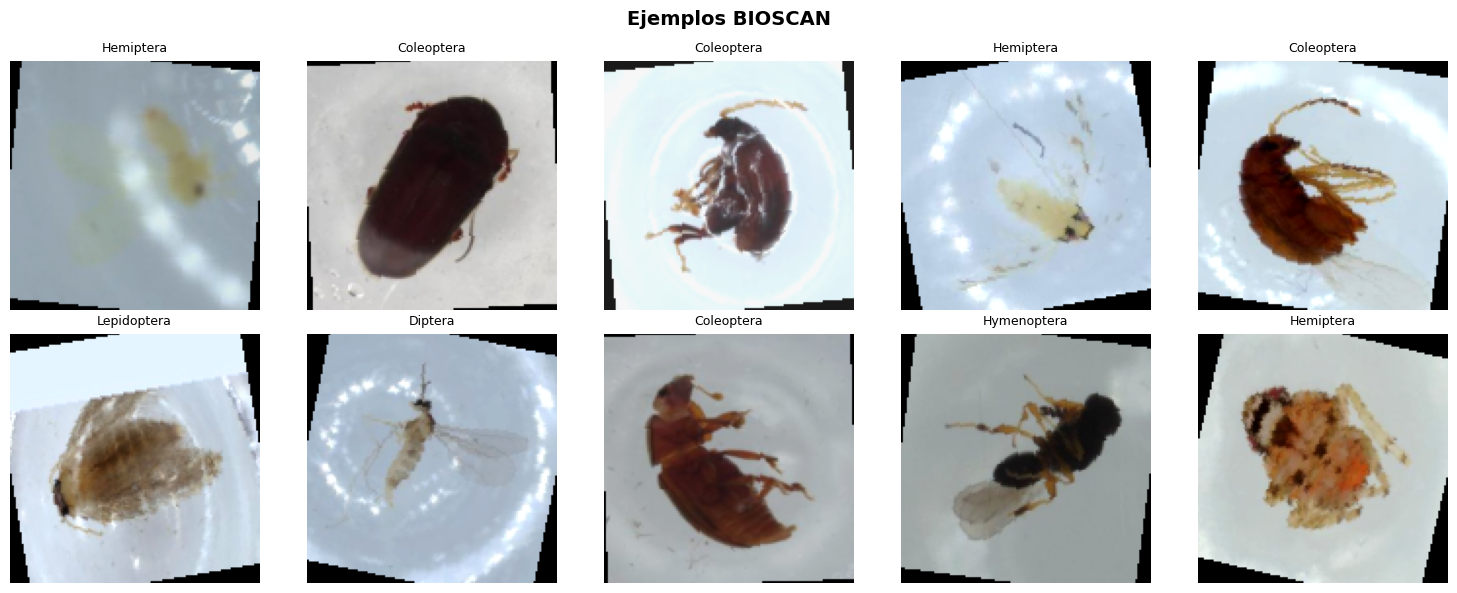

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Ejemplos BIOSCAN', fontsize=14, fontweight='bold')
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for ax in axes.flat:
    idx = random.randint(0, len(train_dataset)-1)
    img_t, label = train_dataset[idx]
    img = img_t.permute(1,2,0).numpy()
    img = np.clip(std * img + mean, 0, 1)
    ax.imshow(img)
    ax.set_title(classes[label], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Arquitectura CNN

Mismo estilo del notebook de referencia.

`
Input  (3, 128, 128)
  |
[Conv1: 3->32]   -> ReLU -> MaxPool  (32, 64, 64)
  |
[Conv2: 32->64]  -> ReLU -> MaxPool  (64, 32, 32)
  |
[Conv3: 64->128] -> ReLU -> MaxPool  (128, 16, 16)
  |
Flatten -> Dropout -> FC(256) -> ReLU -> FC(11)
`

In [10]:
def block(c_in, c_out, k=3, p=1, s=1, pk=2, ps=2):
    return torch.nn.Sequential(
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(pk, stride=ps)
    )

class CNN(torch.nn.Module):
    def __init__(self, n_channels=3, n_outputs=11):
        super().__init__()
        self.conv1   = block(n_channels, 32)
        self.conv2   = block(32, 64)
        self.conv3   = block(64, 128)
        self.dropout = torch.nn.Dropout(0.4)
        self.fc1     = torch.nn.Linear(128 * 16 * 16, 256)
        self.relu    = torch.nn.ReLU()
        self.fc2     = torch.nn.Linear(256, n_outputs)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.shape[0], -1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Verificar forma de salida
model_test = CNN(n_channels=3, n_outputs=11)
out = model_test(torch.randn(4, 3, 128, 128))
print('Forma de salida:', out.shape)   # -> torch.Size([4, 11])
print()
print(model_test)

Forma de salida: torch.Size([4, 11])

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=11, bias=True)
)


## 5. Entrenamiento

In [11]:
def fit(model, dataloader, epochs=10):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()
    history   = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

    for epoch in range(1, epochs+1):
        # --- train ---
        model.train()
        train_loss, train_acc = [], []
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss  = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            train_acc.append(acc)
            bar.set_description('loss {:.5f} acc {:.5f}'.format(np.mean(train_loss), np.mean(train_acc)))

        # --- val ---
        model.eval()
        val_loss, val_acc = [], []
        bar = tqdm(dataloader['val'])
        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss  = criterion(y_hat, y)
                val_loss.append(loss.item())
                acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
                val_acc.append(acc)
                bar.set_description('val_loss {:.5f} val_acc {:.5f}'.format(np.mean(val_loss), np.mean(val_acc)))

        history['train_loss'].append(np.mean(train_loss))
        history['train_acc'].append(np.mean(train_acc))
        history['val_loss'].append(np.mean(val_loss))
        history['val_acc'].append(np.mean(val_acc))
        print('Epoch {}/{} loss {:.5f} val_loss {:.5f} acc {:.5f} val_acc {:.5f}'.format(
            epoch, epochs,
            np.mean(train_loss), np.mean(val_loss),
            np.mean(train_acc),  np.mean(val_acc)))
    return history

In [12]:
model   = CNN(n_channels=3, n_outputs=n_classes)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Parametros entrenables: {:,}'.format(n_params))

history = fit(model, dataloader, epochs=10)

Parametros entrenables: 8,484,939


  0%|          | 0/555 [00:00<?, ?it/s]c:\Users\lucia\Desktop\IA 2\venv\lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
val_loss 1.03598 val_acc 0.64470: 100%|██████████| 119/119 [00:42<00:00,  2.78it/s]


Epoch 1/10 loss 1.26511 val_loss 1.03598 acc 0.55942 val_acc 0.64470


val_loss 0.89388 val_acc 0.69810: 100%|██████████| 119/119 [00:36<00:00,  3.26it/s]


Epoch 2/10 loss 0.99382 val_loss 0.89388 acc 0.66212 val_acc 0.69810


...

Epoch 8/10 loss 0.62144 val_loss 0.67077 acc 0.79203 val_acc 0.77975


val_loss 0.61687 val_acc 0.79723: 100%|██████████| 119/119 [00:42<00:00,  2.78it/s]


Epoch 9/10 loss 0.58559 val_loss 0.61687 acc 0.80523 val_acc 0.79723


val_loss 0.59284 val_acc 0.81671: 100%|██████████| 119/119 [00:48<00:00,  2.45it/s]

Epoch 10/10 loss 0.53573 val_loss 0.59284 acc 0.82048 val_acc 0.81671


## 6. Curvas de entrenamiento

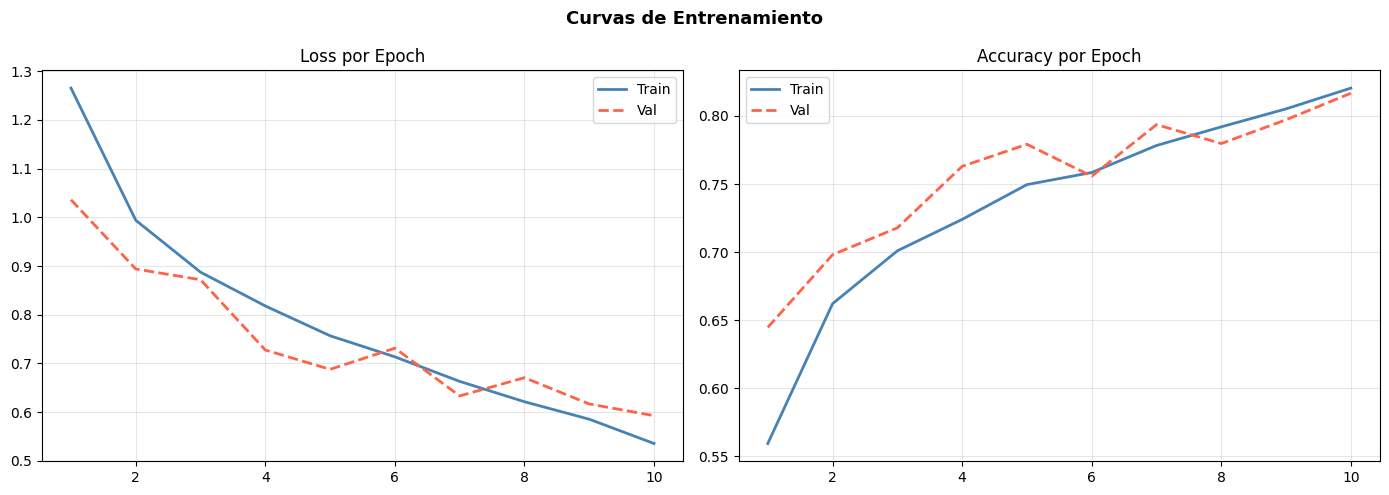

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Entrenamiento', fontsize=13, fontweight='bold')
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   color='tomato',    lw=2, ls='--')
axes[0].set_title('Loss por Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history['train_acc'], label='Train', color='steelblue', lw=2)
axes[1].plot(ep, history['val_acc'],   label='Val',   color='tomato',    lw=2, ls='--')
axes[1].set_title('Accuracy por Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluacion en Test

In [14]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in tqdm(dataloader['test'], desc='Test'):
        X, y  = X.to(device), y.to(device)
        preds = torch.argmax(model(X), axis=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc_global = (all_preds == all_labels).mean()
print('=== TEST ===')
print('Accuracy global: {:.4f} ({:.1f}%)'.format(acc_global, acc_global*100))
print()
print('{:<22} {:>6} {:>10} {:>10}'.format('Clase','Total','Correctas','Accuracy'))
print('-'*52)
for i, clase in enumerate(classes):
    mask      = all_labels == i
    total     = int(mask.sum())
    correctas = int((all_preds[mask] == all_labels[mask]).sum())
    acc_c     = correctas / total if total > 0 else 0
    print('{:<22} {:>6,} {:>10,} {:>9.1f}%'.format(clase, total, correctas, acc_c*100))

Test: 100%|██████████| 119/119 [00:51<00:00,  2.31it/s]

=== TEST ===
Accuracy global: 0.7973 (79.7%)

Clase                   Total  Correctas   Accuracy
----------------------------------------------------
Blattodea                  48         20      41.7%
Coleoptera                750        698      93.1%
Diptera                   750        550      73.3%
Hemiptera                 750        628      83.7%
Hymenoptera               750        644      85.9%
Lepidoptera               373        308      82.6%
Neuroptera                 23          0       0.0%
Orthoptera                 32          7      21.9%
Psocodea                  280        168      60.0%
Thysanoptera               38          9      23.7%
Trichoptera                10          1      10.0%


## 8. Guardar modelo

In [2]:
torch.save(model.state_dict(), 'cnn_bioscan.pth')
print('Modelo guardado: cnn_bioscan.pth')

# Para cargar:
# model2 = CNN(n_channels=3, n_outputs=n_classes)
# model2.load_state_dict(torch.load('cnn_bioscan.pth'))
# model2.eval()

NameError: name 'torch' is not defined

## Resumen

| Componente | Detalle |
|---|---|
| Bloques Conv | Conv2d -> ReLU -> MaxPool2d |
| Capas conv | 3: filtros 32, 64, 128 |
| Entrada imagen | 3 x 128 x 128 px |
| Clases | 11 ordenes BIOSCAN |
| Optimizador | Adam lr=1e-3 |
| Loss | CrossEntropyLoss |
| Regularizacion | Dropout(0.4) + Augmentation |
| Split | 70% train / 15% val / 15% test |

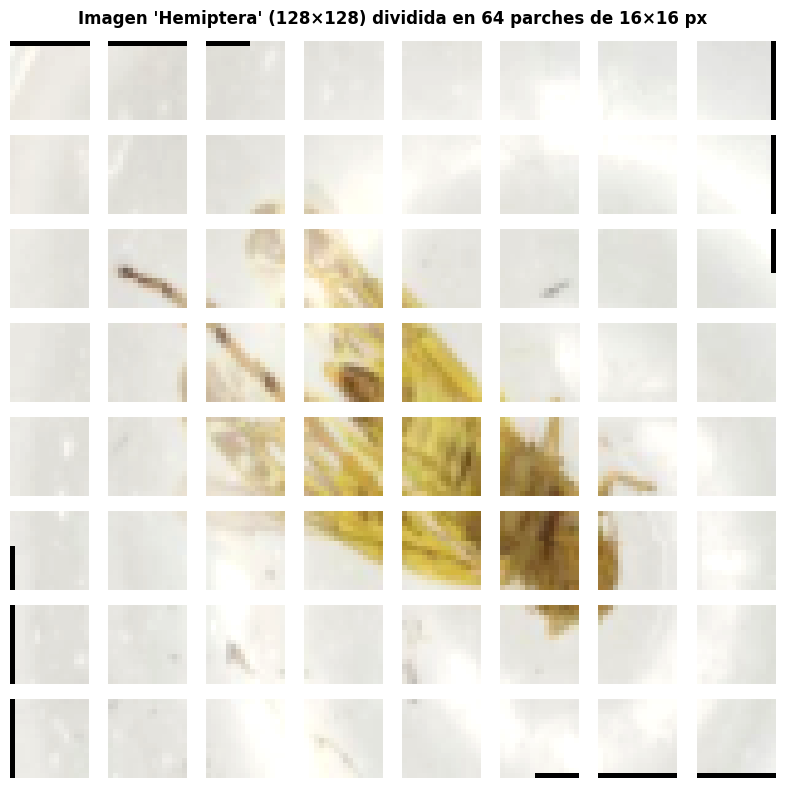

In [ ]:
# ── Visualizar cómo se dividiría una imagen en parches 16×16 ──
PATCH_SIZE = 16                         # cada parche mide 16×16 px
N_PATCHES_SIDE = IMG_SIZE // PATCH_SIZE # 128 / 16 = 8  →  8×8 = 64 parches

sample_idx   = random.randint(0, len(train_dataset) - 1)
sample_t, lbl = train_dataset[sample_idx]

# Desnormalizar para visualizar bien
mean_v = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_v  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
sample_rgb = (sample_t * std_v + mean_v).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(N_PATCHES_SIDE, N_PATCHES_SIDE, figsize=(8, 8))
for row in range(N_PATCHES_SIDE):
    for col in range(N_PATCHES_SIDE):
        patch = sample_rgb[
            row*PATCH_SIZE : (row+1)*PATCH_SIZE,
            col*PATCH_SIZE : (col+1)*PATCH_SIZE
        ]
        axes[row, col].imshow(patch)
        axes[row, col].axis('off')

plt.suptitle(
    f"Imagen '{classes[lbl]}' (128×128) dividida en {N_PATCHES_SIDE*N_PATCHES_SIDE} parches de {PATCH_SIZE}×{PATCH_SIZE} px",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 9.1 Código del modelo — `SimpleAttentionModel`

Tres piezas principales, cada una con un comentario explicativo:

| Pieza | Capa PyTorch | ¿Qué hace? |
|---|---|---|
| **Patch Embedding** | `nn.Conv2d(3, d, 16, stride=16)` | Corta la imagen en parches y los proyecta a un vector |
| **Positional Embedding** | `nn.Parameter(zeros)` | Dice dónde estaba cada parche |
| **Atención + MLP** | `nn.MultiheadAttention` + `nn.Linear` | Relaciona parches y aprende qué zonas mirar |

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleAttentionModel(nn.Module):
    """
    Vision Transformer sencillo para clasificar insectos BIOSCAN.
    Entrada : (Batch, 3, 128, 128)
    Salida  : (Batch, n_classes)
    """
    def __init__(self, img_size=128, patch_size=16, n_channels=3,
                 d_model=128, n_heads=4, n_classes=11):
        super().__init__()

        self.num_patches = (img_size // patch_size) ** 2  # 64 parches

        self.patch_proj = nn.Conv2d(
            n_channels, d_model,
            kernel_size=patch_size, stride=patch_size
        )

        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, d_model)
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.mha   = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads, batch_first=True
        )

    
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp   = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_model * 2, d_model),
        )

        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(d_model, n_classes)

    def forward(self, x):
        # x: (B, 3, 128, 128)

        # Paso 1 — parches → vectores
        x = self.patch_proj(x)            # (B, d_model, 8, 8)
        x = x.flatten(2).transpose(1, 2)  # (B, 64, d_model)

        # Paso 2 — sumar posición
        x = x + self.pos_embed            # (B, 64, d_model)

        # Paso 3 — Multi-Head Attention + conexión residual
        norm_x    = self.norm1(x)
        attn_out, _ = self.mha(norm_x, norm_x, norm_x)
        x = x + attn_out                  # (B, 64, d_model)

        # Paso 4 — MLP + conexión residual
        x = x + self.mlp(self.norm2(x))   # (B, 64, d_model)

        # Paso 5 — promediar los 64 parches y clasificar
        x = x.mean(dim=1)                 # (B, d_model)
        x = self.dropout(x)
        return self.fc(x)                 # (B, n_classes)

# ── Verificar dimensiones ──
_test = SimpleAttentionModel(n_classes=n_classes)
_out  = _test(torch.randn(4, 3, 128, 128))
print('Forma de salida:', _out.shape)     # torch.Size([4, 11])
print()
print(_test)

Forma de salida: torch.Size([4, 11])

SimpleAttentionModel(
  (patch_proj): Conv2d(3, 128, kernel_size=(16, 16), stride=(16, 16))
  (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (mha): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=11, bias=True)
)


### 9.2 Verificación dimensional paso a paso

In [11]:
# ── Seguir las dimensiones del tensor por cada capa ──
_m     = SimpleAttentionModel(n_classes=n_classes).to(device)
_dummy = torch.randn(4, 3, 128, 128).to(device)

with torch.no_grad():
    _proj   = _m.patch_proj(_dummy)          # (4, 128, 8, 8)
    _tokens = _proj.flatten(2).transpose(1,2)# (4, 64, 128)
    _out    = _m(_dummy)

print("─" * 52)
print(f"  Entrada original     : {tuple(_dummy.shape)}")
print(f"  Tras patch_proj      : {tuple(_proj.shape)}")
print(f"  Secuencia de tokens  : {tuple(_tokens.shape)}  ← 64 parches × d_model=128")
print(f"  Salida (logits)      : {tuple(_out.shape)}")
print("─" * 52)

_n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
# _n_cnn    = sum(p.numel() for p in CNN(3, n_classes).parameters() if p.requires_grad)
# print(f"  Parámetros CNN       : {_n_cnn:>12,}")
print(f"  Parámetros MHA       : {_n_params:>12,}")

────────────────────────────────────────────────────
  Entrada original     : (4, 3, 128, 128)
  Tras patch_proj      : (4, 128, 8, 8)
  Secuencia de tokens  : (4, 64, 128)  ← 64 parches × d_model=128
  Salida (logits)      : (4, 11)
────────────────────────────────────────────────────
  Parámetros MHA       :      240,523


### 9.3 Entrenamiento del modelo Multi-Head Attention

Usamos la **misma función `fit`** que entrenó la CNN, sin cambiar nada.

In [12]:
mha_model  = SimpleAttentionModel(n_classes=n_classes)
mha_params = sum(p.numel() for p in mha_model.parameters() if p.requires_grad)
print(f'Parámetros entrenables MHA: {mha_params:,}')

mha_history = fit(mha_model, dataloader, epochs=10)

Parámetros entrenables MHA: 240,523


NameError: name 'fit' is not defined

### 9.4 Curvas de aprendizaje comparativas — CNN vs. Multi-Head Attention

In [ ]:
ep = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('CNN vs. Multi-Head Attention — BIOSCAN', fontsize=14, fontweight='bold')

# ── Loss ──
axes[0].plot(ep, history['train_loss'],     'b-o',  label='CNN  Train',  lw=2)
axes[0].plot(ep, history['val_loss'],       'b--o', label='CNN  Val',    lw=2)
axes[0].plot(ep, mha_history['train_loss'], 'r-s',  label='MHA  Train',  lw=2)
axes[0].plot(ep, mha_history['val_loss'],   'r--s', label='MHA  Val',    lw=2)
axes[0].set_title('Pérdida (Loss)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── Accuracy ──
axes[1].plot(ep, [a*100 for a in history['train_acc']],     'b-o',  label='CNN  Train',  lw=2)
axes[1].plot(ep, [a*100 for a in history['val_acc']],       'b--o', label='CNN  Val',    lw=2)
axes[1].plot(ep, [a*100 for a in mha_history['train_acc']], 'r-s',  label='MHA  Train',  lw=2)
axes[1].plot(ep, [a*100 for a in mha_history['val_acc']],   'r--s', label='MHA  Val',    lw=2)
axes[1].set_title('Precisión (Accuracy %)')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Tabla resumen numérica ──
cnn_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
mha_params = sum(p.numel() for p in mha_model.parameters() if p.requires_grad)

print("+" + "─"*66 + "+")
print(f"| {'Métrica':<30} | {'CNN':<15} | {'Multi-Head Attn':<15} |")
print("+" + "─"*66 + "+")
print(f"| {'Parámetros entrenables':<30} | {cnn_params:<15,} | {mha_params:<15,} |")
print(f"| {'Best Val Accuracy':<30} | {max(history['val_acc'])*100:<14.2f}% | {max(mha_history['val_acc'])*100:<14.2f}% |")
print(f"| {'Val Loss final':<30} | {history['val_loss'][-1]:<15.4f} | {mha_history['val_loss'][-1]:<15.4f} |")
print("+" + "─"*66 + "+")

### 9.5 Predicciones de muestra — CNN vs. Multi-Head Attention

In [ ]:
model.eval()
mha_model.eval()
mha_model.to(device)

sample_ids = random.sample(range(len(test_dataset)), 8)
fig, axes  = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

mean_v = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_v  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

with torch.no_grad():
    for i, idx in enumerate(sample_ids):
        img_t, true_y = test_dataset[idx]
        img_in = img_t.unsqueeze(0).to(device)

        pred_cnn = model(img_in).argmax(1).item()
        pred_mha = mha_model(img_in).argmax(1).item()

        img_rgb = (img_t * std_v + mean_v).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[i].imshow(img_rgb)

        ok_c = '✓' if pred_cnn == true_y else '✗'
        ok_m = '✓' if pred_mha == true_y else '✗'
        axes[i].set_title(
            f"Real: {classes[true_y]}\n"
            f"CNN: {ok_c} {classes[pred_cnn]}\n"
            f"MHA: {ok_m} {classes[pred_mha]}",
            fontsize=9, fontweight='bold'
        )
        axes[i].axis('off')

plt.suptitle('Predicciones en Test: CNN vs. Multi-Head Attention', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 10. Conclusiones — ¿CNN o Multi-Head Attention?

| | **CNN** | **Multi-Head Attention** |
|---|---|---|
| **Cómo ve la imagen** | Filtros locales 3×3 (solo vecinos) | Todos los parches se ven entre sí al mismo tiempo |
| **Sesgo espacial** | Muy fuerte (asume vecindad = relación) | Débil (aprende las relaciones desde cero) |
| **Ideal para** | Datasets pequeños/medianos, GPU limitada | Datasets grandes, modelos fundacionales |
| **Con BIOSCAN (11 clases)** | Converge rápido y bien desde la época 1 | Necesita más épocas o datos para igual rendimiento |

**¿Por qué la CNN suele ganar en datasets pequeños?**
Porque ya viene con "conocimiento incorporado": sabe que los píxeles cercanos forman bordes y texturas. El modelo de atención tiene que aprender eso de cero.

**¿Por qué existen los Transformers si la CNN gana aquí?**
Cuando los datasets son enormes (millones de imágenes), el modelo de atención puede capturar relaciones mucho más complejas y supera a las CNNs — es el caso de modelos como ViT-Large, CLIP o DINOv2.